In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# %pip install sncosmo
# %pip install sfdmap2
# %pip install lightcurvelynx
# %pip install nested-pandas --upgrade
# %pip install pandas --upgrade
# %pip install lsdb --upgrade

In [3]:
import matplotlib.pyplot as plt
import lsdb
import numpy as np
from lightcurvelynx.astro_utils.mag_flux import flux2mag
from astropy.cosmology import Planck18
from astropy.coordinates import Distance
import astropy.units as u
from joblib import Parallel, delayed
import pandas as pd
from nested_pandas import read_parquet
import sncosmo
import nested_pandas as npd
from utils import nightly_coadd

from dask.distributed import Client

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
client = Client(n_workers=40, memory_limit="10 GiB", threads_per_worker=1)
display(client)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 32815 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:32815/status,
Dashboard: http://127.0.0.1:32815/status,Workers: 40
Total threads: 40,Total memory: 400.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37649,Workers: 0
Dashboard: http://127.0.0.1:32815/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43253,Total threads: 1
Dashboard: http://127.0.0.1:45827/status,Memory: 10.00 GiB
Nanny: tcp://127.0.0.1:33659,


2026-07-25 02:48:06,396 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='localhost:8787', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/tornado/web.py", line 3409, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.pro

In [5]:
import os
os.environ["SFD_DIR"] = "/astro/users/midai/sfdmap2/sfddata-master"

In [6]:
DDF = False
refit_salt = True
SKIP_BAZIN = True

In [7]:
from pathlib import Path
outdir = Path('outputs/')

In [8]:
columns = ["max_reliability","max_snr","ndet","nbands","n_g","n_r","n_i","n_z","dt",
           "median_flux_diff_ratio","median_flux_diff_ratio_abs","_dist_arcsec"]
bins_map = {"median_flux_diff_ratio": np.linspace(0,5,20),
        "median_flux_diff_ratio_abs": np.linspace(0,1,20)}
if DDF:
    sncandid_filename = "sncandid_w_bazin_ddf"
else:
    sncandid_filename = "sncandid_w_bazin"
sncat_meta = lsdb.open_catalog(outdir / sncandid_filename,columns=columns)

In [9]:
len(sncat_meta)

56647

In [10]:
snmeta = sncat_meta.head(200)

Computing Catalog: 100%|██████████| 1/1 [00:00<00:00, 65.23it/s]


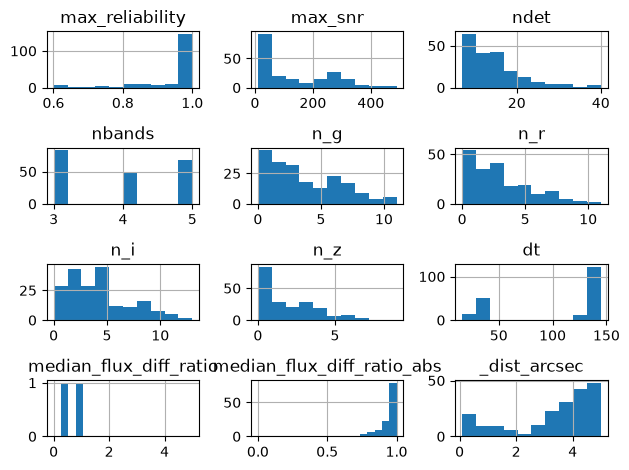

In [11]:
for i,col in enumerate(columns):
    plt.subplot(4,3,i+1)
    if col in bins_map.keys():
        bins = bins_map[col]
    else:
        bins = None
    snmeta[col].hist(bins=bins)
    plt.title(col)
plt.tight_layout()
plt.show()

In [12]:
bazin_cols = [f"bazin_fit_reduced_chi2_{b}" for b in "griz"]
sncat_bazin = lsdb.open_catalog(outdir / sncandid_filename,columns=bazin_cols)

In [13]:
snbazin = sncat_bazin.head(200)

Computing Catalog: 100%|██████████| 1/1 [00:00<00:00, 39.76it/s]


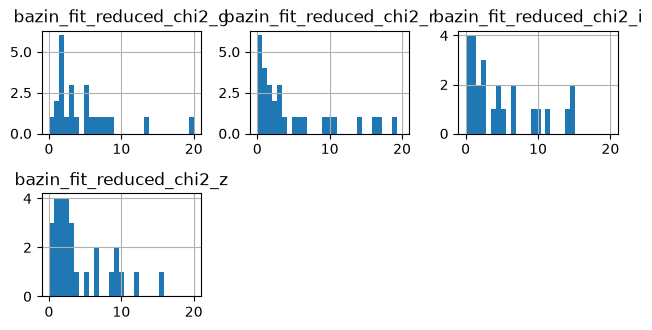

In [14]:
for i,col in enumerate(bazin_cols):
    plt.subplot(3,3,i+1)
    snbazin[col].hist(bins=np.linspace(0,20,30))
    plt.title(col)
plt.tight_layout()
plt.show()

In [15]:
sncat = lsdb.open_catalog(outdir / sncandid_filename)

In [16]:
def filter_bazin(df):
    df = df.query("((bazin_fit_reduced_chi2_r > 0.1 and bazin_fit_reduced_chi2_r < 10.0) or "
                  "(bazin_fit_reduced_chi2_g > 0.1 and bazin_fit_reduced_chi2_g < 10.0) or "
                  "(bazin_fit_reduced_chi2_i > 0.1 and bazin_fit_reduced_chi2_i < 10.0) or "
                  "(bazin_fit_reduced_chi2_z > 0.1 and bazin_fit_reduced_chi2_z < 10.0))")
    return df

In [17]:
if not SKIP_BAZIN:
    sn_good = sncat.map_partitions(filter_bazin)
else:
    sn_good = sncat

In [18]:
if DDF:
    goodsn_filename = "good_sne_ddf"
else:
    goodsn_filename = "good_sne"
print(goodsn_filename)

good_sne


In [19]:
sn_good.write_catalog(outdir / goodsn_filename,overwrite=True)

Writing Catalog: 100%|██████████| 8534/8534 [00:35<00:00, 243.28it/s]


In [20]:
sn_good = lsdb.open_catalog(outdir / goodsn_filename)

In [21]:
len(sn_good)

56647

In [22]:
head = sn_good.head()
head

Computing Catalog: 100%|██████████| 1/1 [00:00<00:00, 33.57it/s]


diaObjectId_dia_object_lc  ra_dia_object_lc  \
_healpix_29                                                        
1197932380636954440         769117592039194662        353.924572   
1199913362631869280         765865099205279819        344.451449   
1200208372090499939         767473890875146242        345.925452   
1200382490267765652         764254864426401796        340.006929   
1200435051995468840         764263523080470529        340.472904   

                     dec_dia_object_lc  refExtendedness_object_lc  \
_healpix_29                                                         
1197932380636954440          -15.12938                        1.0   
1199913362631869280         -18.648139                        1.0   
1200208372090499939          -17.06852                        1.0   
1200382490267765652         -20.605294                        1.0   
1200435051995468840         -20.272686                        1.0   

                     refSizeExtendedness_object_lc  objectId_object_lc  \
_healpix_29                                                              
1197932380636954440                       0.999753  769117592039216047   
1199913362631869280                            1.0  765865099205302476   
1200208372090499939                            1.0  767473890875164932   
1200382490267765652                            1.0  764254864426423160   
1200435051995468840                            1.0  764263523080489646   

                     coord_ra_object_lc  coord_dec_object_lc  _dist_arcsec  \
_healpix_29                                                                  
1197932380636954440          353.924012           -15.128647      3.276718   
1199913362631869280          344.452621           -18.648198      4.000907   
1200208372090499939          345.924325           -17.069157      4.503291   
1200382490267765652           340.00809           -20.605036      4.021165   
1200435051995468840          340.471732           -20.273395      4.707227   

                     ndet  ...  bazin_fit_reference_time_z  \
_healpix_29                ...                               
1197932380636954440     7  ...                        <NA>   
1199913362631869280    18  ...                        <NA>   
1200208372090499939    11  ...                        <NA>   
1200382490267765652    10  ...                        <NA>   
1200435051995468840    11  ...                        <NA>   

                     bazin_fit_rise_time_z  bazin_fit_fall_time_z  \
_healpix_29                                                         
1197932380636954440                   <NA>                   <NA>   
1199913362631869280                   <NA>                   <NA>   
1200208372090499939                   <NA>                   <NA>   
1200382490267765652                   <NA>                   <NA>   
1200435051995468840                   <NA>                   <NA>   

                     bazin_fit_reduced_chi2_z        chi2_g        chi2_r  \
_healpix_29                                                                 
1197932380636954440                      <NA>      1.121956     11.193762   
1199913362631869280                      <NA>  49467.144531  12830.367188   
1200208372090499939                      <NA>     85.597572    826.755066   
1200382490267765652                      <NA>      0.115136    320.793701   
1200435051995468840                      <NA>     12.917845    185.115967   

                           chi2_i      chi2_z  \
_healpix_29                                     
1197932380636954440     19.785179    1.034268   
1199913362631869280   6774.501953  328.836121   
1200208372090499939     380.85672    0.433459   
1200382490267765652  362380.84375   25.590889   
1200435051995468840   207715.9375  154.792679   

                                   diaObjectForcedSource_dia_object_lc  \
_healpix_29                                                              
1197932380636954440  [{midpointMjdTai: 6085

In [23]:
colors = {"u": "pink",
          "g": "green",
          "r": "red",
          "i": "purple",
          "z": "orange",
          "y": "brown"}
def plot_lc(lc,saltpars=None):
    maxflux = 0.
    for f in lc["band"].unique():
        lc_f = lc.loc[lc["band"]==f]
        is_det = np.absolute(lc_f["snr"]) > 5
        lc_det = lc_f.loc[is_det]
        lc_nondet = lc_f.loc[~is_det]
        plt.errorbar(lc_det["mjd"],lc_det["flux"],yerr=lc_det["fluxerr"],fmt='o',label=f, c=colors[f])
        plt.errorbar(lc_nondet["mjd"],lc_nondet["flux"],yerr=lc_nondet["fluxerr"],fmt='>',alpha=0.3, c=colors[f])

        if saltpars is not None:
            model = sncosmo.Model("salt3",effects=[sncosmo.F99Dust()], effect_names=["mw"], effect_frames=["obs"])
            model.update(saltpars)
            time = np.linspace(-20,50,100)*(1.+saltpars["z"]) + saltpars["t0"]
            try:
                flux = model.bandflux("lsst"+f,time,zp=31.4, zpsys='ab')
                maxflux = np.max(np.append(flux,maxflux))
                plt.plot(time,flux,c=colors[f],alpha=0.1,ls="--")
            except:
                continue
        plt.legend()
    is_det = np.absolute(lc["snr"]) > 5
    if saltpars:
        ylim = (-0.2*maxflux, maxflux*1.5)
    else:
        ylim = (-0.2*lc.loc[is_det]["flux"].max(),lc.loc[is_det]["flux"].max()*1.5)
    # plt.ylim(ylim)

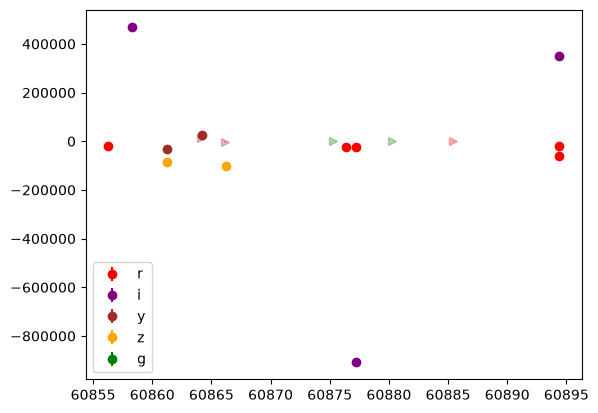

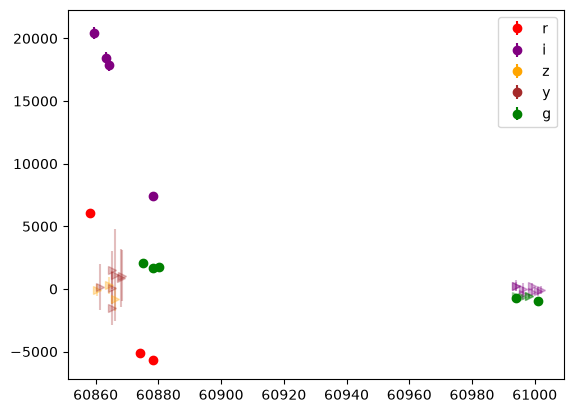

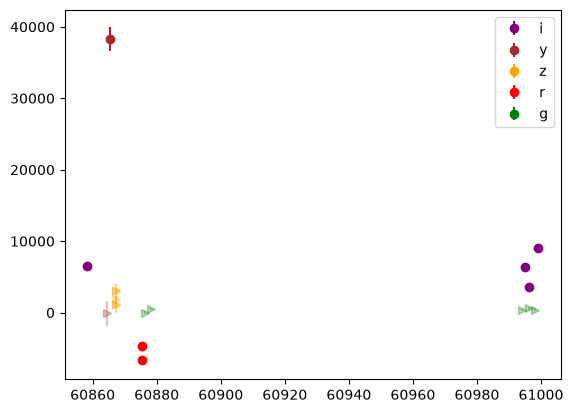

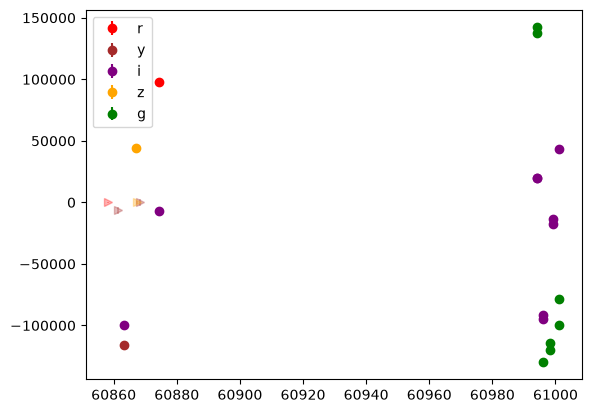

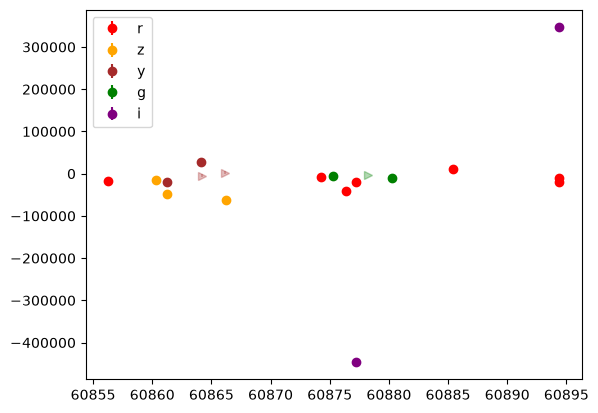

In [24]:
sn = head
for i in np.random.choice(len(sn),size=np.min([20,len(sn)]),replace=False):
    # plt.subplot(2,1,1)
    lc = sn.iloc[i]["diaObjectForcedSource_dia_object_lc"]
    lc = lc[["midpointMjdTai","band","psfDiffFlux","psfDiffFluxErr"]]
    lc["mjd"] = lc["midpointMjdTai"]
    lc["flux"] = lc["psfDiffFlux"]
    lc["fluxerr"] = lc["psfDiffFluxErr"]
    lc["snr"] = lc["flux"]/lc["fluxerr"]
    plot_lc(lc)
    # plt.subplot(2,1,2)
    # lc = sn.iloc[i]["diaSource_dia_object_lc"]
    # lc = lc[["midpointMjdTai","band","psfFlux","psfFluxErr"]]
    # lc["mjd"] = lc["midpointMjdTai"]
    # lc["flux"] = lc["psfFlux"]
    # lc["fluxerr"] = lc["psfFluxErr"]
    # lc["snr"] = lc["flux"]/lc["fluxerr"]
    # plot_lc(lc)
    plt.show()

In [25]:
def lc_quality_cuts(flux,mjd,filter,snr, n_phases=5, n_before_peak=1, n_after_peak=2, n_bands=3):
    det = snr > 5
    flux = flux[det]
    mjd = mjd[det]
    filter = filter[det]
    if len(flux) == 0:
        return False
    peak_idx = np.argmax(flux)
    phases = np.floor((mjd - mjd[peak_idx]))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -40) & (unique_phases<=100)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    flux_new = flux[unique_idx][good_idx]
    peak_idx_new = np.argmax(flux_new)
    pass_cut &= (peak_idx_new >= n_before_peak - 1) & (len(flux_new) - peak_idx_new >= n_after_peak - 1)
    good_phases = (phases >= -40) & (phases<=100)
    pass_cut &= len(np.unique(filter[good_phases])) >= n_bands
    return pass_cut

In [26]:
def make_lc_quality_cuts(df):
    df["diaObjectForcedSource_dia_object_lc.snr"] = df["diaObjectForcedSource_dia_object_lc.psfDiffFlux"]/df["diaObjectForcedSource_dia_object_lc.psfDiffFluxErr"]
    if len(df) == 0:
        df = df.assign(**{name: np.array([], dtype=bool) for name in ["pass_quality_cut"]}) 
    else:
        df = df.map_rows(lc_quality_cuts,columns=["diaObjectForcedSource_dia_object_lc.psfDiffFlux",
                                       "diaObjectForcedSource_dia_object_lc.midpointMjdTai",
                                       "diaObjectForcedSource_dia_object_lc.band",
                                       "diaObjectForcedSource_dia_object_lc.snr"],
                                       row_container="args",output_names=["pass_quality_cut"], 
                                       append_columns=True)
    return df

In [27]:
sn_good_after_quality_cut = sn_good.map_partitions(make_lc_quality_cuts)

In [28]:
good_qc_filename = "good_sne_after_quality_cut"

In [29]:
sn_good_after_quality_cut = sn_good_after_quality_cut.query("pass_quality_cut == True")

In [30]:
sn_good_after_quality_cut.head()

Computing Catalog: 100%|██████████| 1/1 [00:00<00:00, 14.00it/s]


diaObjectId_dia_object_lc  ra_dia_object_lc  \
_healpix_29                                                        
1200208372090499939         767473890875146242        345.925452   
1200465576647293282         764256994730180612        339.905651   
1200785904850779412         764256651132796951         338.91889   
1200845017146712741         764257819363901496        339.498045   
1200883739342177866         764259880948203526        339.559885   

                     dec_dia_object_lc  refExtendedness_object_lc  \
_healpix_29                                                         
1200208372090499939          -17.06852                        1.0   
1200465576647293282         -20.147871                        1.0   
1200785904850779412         -20.340729                        1.0   
1200845017146712741         -19.977717                        1.0   
1200883739342177866         -19.467459                        1.0   

                     refSizeExtendedness_object_lc  objectId_object_lc  \
_healpix_29                                                              
1200208372090499939                            1.0  767473890875164932   
1200465576647293282                            1.0  764256994730200287   
1200785904850779412                            1.0  764256651132816445   
1200845017146712741                            1.0  764257819363921111   
1200883739342177866                            1.0  764259880948226844   

                     coord_ra_object_lc  coord_dec_object_lc  _dist_arcsec  \
_healpix_29                                                                  
1200208372090499939          345.924325           -17.069157      4.503291   
1200465576647293282          339.905542           -20.148758      3.212641   
1200785904850779412          338.919773           -20.341296      3.612958   
1200845017146712741          339.497775           -19.977911      1.148908   
1200883739342177866          339.558508           -19.467094      4.851968   

                     ndet  ...  bazin_fit_rise_time_z  bazin_fit_fall_time_z  \
_healpix_29                ...                                                 
1200208372090499939    11  ...                   <NA>                   <NA>   
1200465576647293282    13  ...                   <NA>                   <NA>   
1200785904850779412    19  ...                   <NA>                   <NA>   
1200845017146712741    10  ...                   <NA>                   <NA>   
1200883739342177866    10  ...                   <NA>                   <NA>   

                     bazin_fit_reduced_chi2_z       chi2_g       chi2_r  \
_healpix_29                                                               
1200208372090499939                      <NA>    85.597572   826.755066   
1200465576647293282                      <NA>   489.055481  1158.308228   
1200785904850779412                      <NA>  1010.743896  9849.060547   
1200845017146712741                      <NA>    42.402779   386.735474   
1200883739342177866                      <NA>    35.670322    51.351063   

                           chi2_i       chi2_z  \
_healpix_29                                      
1200208372090499939     380.85672     0.433459   
1200465576647293282      4.225089    28.198563   
1200785904850779412   6163.311523  5146.881348   
1200845017146712741     228365.25    43.431427   
1200883739342177866  310356.28125    18.690752   

                                   diaObjectForcedSource_dia_object_lc  \
_healpix_29                                                              
1200208372090499939  [{midpointMjdTai: 60858.284129, band: 'r', psf...   
1200465576647293282  [{midpointMjdTai: 60856.281898, band: 'r', psf...   
1200785904850779412  [{midpointMjdTai: 60856.281898, band: 'r', psf...   
1200845017146712741  [{midpointMjdTai: 60856.281898, band: 'r', psf...   
1200883739342177866  [{midpointMjdTai: 60856.281898, band: 'r', psf...   

                                     

In [31]:
sn_good_after_quality_cut.write_catalog(outdir / good_qc_filename,overwrite=True)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 10.22 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
Writing Catalog: 100%|██████████| 8534/8534 [01:12<00:00, 118.49it/s]


In [32]:
sn_good_after_quality_cut = lsdb.open_catalog(outdir / good_qc_filename)
len(sn_good_after_quality_cut)

38215

In [33]:
head = sn_good_after_quality_cut.head()

Computing Catalog: 100%|██████████| 1/1 [00:00<00:00, 27.21it/s]


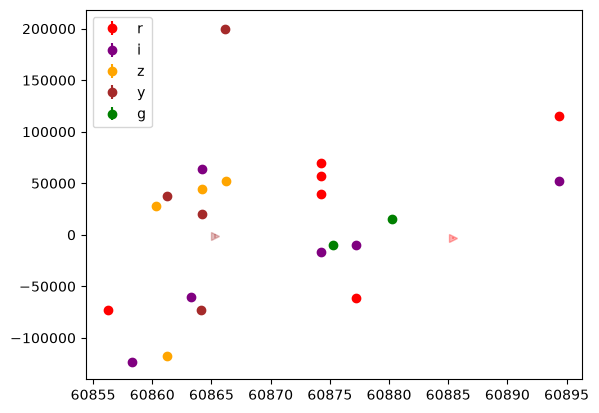

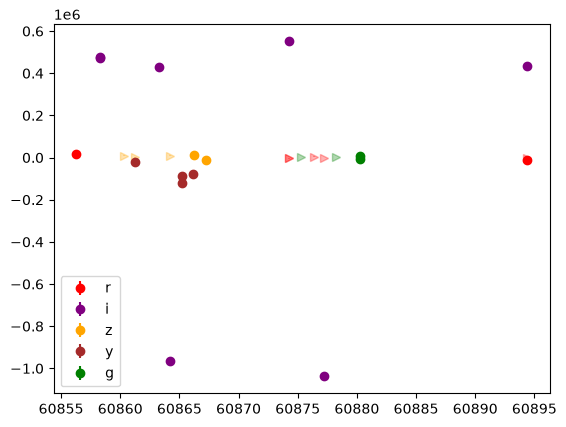

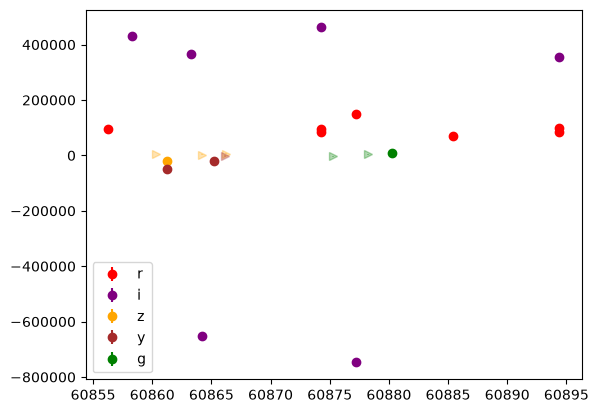

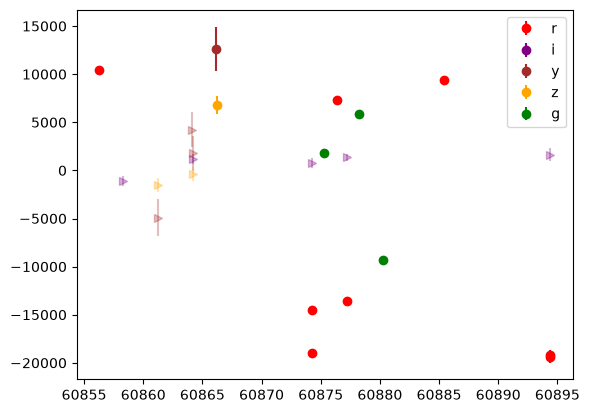

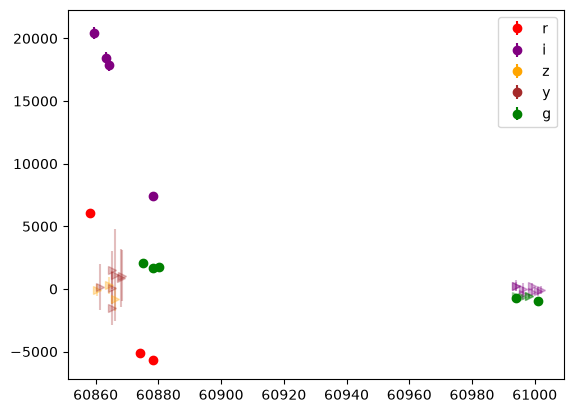

In [34]:
sn = head
for i in np.random.choice(len(sn),size=np.min([20,len(sn)]),replace=False):
    # plt.subplot(2,1,1)
    lc = sn.iloc[i]["diaObjectForcedSource_dia_object_lc"]
    lc = lc[["midpointMjdTai","band","psfDiffFlux","psfDiffFluxErr"]]
    lc["mjd"] = lc["midpointMjdTai"]
    lc["flux"] = lc["psfDiffFlux"]
    lc["fluxerr"] = lc["psfDiffFluxErr"]
    lc["snr"] = lc["flux"]/lc["fluxerr"]
    plot_lc(lc)
    # plt.subplot(2,1,2)
    # lc = sn.iloc[i]["diaSource_dia_object_lc"]
    # lc = lc[["midpointMjdTai","band","psfFlux","psfFluxErr"]]
    # lc["mjd"] = lc["midpointMjdTai"]
    # lc["flux"] = lc["psfFlux"]
    # lc["fluxerr"] = lc["psfFluxErr"]
    # lc["snr"] = lc["flux"]/lc["fluxerr"]
    # plot_lc(lc)
    plt.show()

In [35]:
from lcfit import fit_single_lc  

def fit_single_lc_w_cond(lc,
                         bounds={"x1": (-4,4),
                                 "c": (-0.4,0.8),},
                         phase_range=(-15,45),
                         modelcov=False):
    return fit_single_lc(lc,mpbounds=bounds,phase_range=phase_range,modelcov=modelcov)

In [36]:
def infer_z_from_peakmag(row):
    peakflux = np.max(row)
    peakmag = flux2mag(peakflux)
    z = Distance(distmod = peakmag + 19).compute_z(cosmology=Planck18).value
    return z

In [37]:
def compute_z_from_peakmag(df):
    if len(df) == 0:
        df = df.assign(**{name: np.array([], dtype=np.float32) for name in ["z_est"]}) 
    else:
        df = df.map_rows(infer_z_from_peakmag, columns=["diaSource_dia_object_lc.psfFlux"], row_container="args",
                         output_names=["z_est"], append_columns=True)
    return df

In [38]:
def fit_salt2(df):
    saltcolumns = ['success', 'ncall', 'chisq', 'ndof', 'z', 'z_err', 't0', 't0_err', 'x0',
           'x0_err', 'x1', 'x1_err', 'c', 'c_err', 'mwebv', 'mwebv_err', 'z_z_cov',
           'z_t0_cov', 'z_x0_cov', 'z_x1_cov', 'z_c_cov', 'z_mwebv_cov',
           't0_z_cov', 't0_t0_cov', 't0_x0_cov', 't0_x1_cov', 't0_c_cov',
           't0_mwebv_cov', 'x0_z_cov', 'x0_t0_cov', 'x0_x0_cov', 'x0_x1_cov',
           'x0_c_cov', 'x0_mwebv_cov', 'x1_z_cov', 'x1_t0_cov', 'x1_x0_cov',
           'x1_x1_cov', 'x1_c_cov', 'x1_mwebv_cov', 'c_z_cov', 'c_t0_cov',
           'c_x0_cov', 'c_x1_cov', 'c_c_cov', 'c_mwebv_cov', 'mwebv_z_cov',
           'mwebv_t0_cov', 'mwebv_x0_cov', 'mwebv_x1_cov', 'mwebv_c_cov',
           'mwebv_mwebv_cov', 'id', 'fit_error']
    dtypes = [np.float64]*(len(saltcolumns)-2)+ [int] + [str]
    if len(df) == 0:
        df = df.assign(**{name: np.array([], dtype=dtype) for name,dtype in zip(saltcolumns,dtypes)}) 
    else:
        df = df.map_rows(fit_single_lc_w_cond, 
                         columns=["ra_dia_object_lc","dec_dia_object_lc","diaObjectId_dia_object_lc", "z_est",
                                  "diaSource_dia_object_lc.midpointMjdTai", "diaSource_dia_object_lc.band",
                                  "diaSource_dia_object_lc.psfFlux","diaSource_dia_object_lc.psfFluxErr"], 
                         append_columns=True)
    return df

In [39]:
sn_good_after_quality_cut = lsdb.open_catalog(outdir / good_qc_filename)
sn_good_after_quality_cut = sn_good_after_quality_cut.map_partitions(compute_z_from_peakmag)

In [40]:
# # for debugging
# sn_good_after_quality_cut = sn_good_after_quality_cut.partitions[0:100]

In [41]:
res = sn_good_after_quality_cut.map_partitions(fit_salt2,compute_single_partition=False)

In [42]:
head = res.head()

Computing Catalog: 100%|██████████| 1/1 [00:01<00:00,  1.34s/it]


In [43]:
head

diaObjectId_dia_object_lc  ra_dia_object_lc  \
_healpix_29                                                        
1200208372090499939         767473890875146242        345.925452   
1200465576647293282         764256994730180612        339.905651   
1200785904850779412         764256651132796951         338.91889   
1200845017146712741         764257819363901496        339.498045   
1200883739342177866         764259880948203526        339.559885   

                     dec_dia_object_lc  refExtendedness_object_lc  \
_healpix_29                                                         
1200208372090499939          -17.06852                        1.0   
1200465576647293282         -20.147871                        1.0   
1200785904850779412         -20.340729                        1.0   
1200845017146712741         -19.977717                        1.0   
1200883739342177866         -19.467459                        1.0   

                     refSizeExtendedness_object_lc  objectId_object_lc  \
_healpix_29                                                              
1200208372090499939                            1.0  767473890875164932   
1200465576647293282                            1.0  764256994730200287   
1200785904850779412                            1.0  764256651132816445   
1200845017146712741                            1.0  764257819363921111   
1200883739342177866                            1.0  764259880948226844   

                     coord_ra_object_lc  coord_dec_object_lc  _dist_arcsec  \
_healpix_29                                                                  
1200208372090499939          345.924325           -17.069157      4.503291   
1200465576647293282          339.905542           -20.148758      3.212641   
1200785904850779412          338.919773           -20.341296      3.612958   
1200845017146712741          339.497775           -19.977911      1.148908   
1200883739342177866          339.558508           -19.467094      4.851968   

                     ndet  ...       c_c_cov  c_mwebv_cov  mwebv_z_cov  \
_healpix_29                ...                                           
1200208372090499939    11  ...  1.412580e-04          0.0          0.0   
1200465576647293282    13  ...  1.673739e-01          0.0          0.0   
1200785904850779412    19  ...  2.315022e-07          0.0          0.0   
1200845017146712741    10  ...  3.935078e-05          0.0          0.0   
1200883739342177866    10  ...  4.142169e-15          0.0          0.0   

                     mwebv_t0_cov  mwebv_x0_cov  mwebv_x1_cov  mwebv_c_cov  \
_healpix_29                                                                  
1200208372090499939           0.0           0.0           0.0          0.0   
1200465576647293282           0.0           0.0           0.0          0.0   
1200785904850779412           0.0           0.0           0.0          0.0   
1200845017146712741           0.0           0.0           0.0          0.0   
1200883739342177866           0.0           0.0           0.0          0.0   

                     mwebv_mwebv_cov                  id  fit_error  
_healpix_29                                                          
1200208372090499939              0.0  767473890875146242       None  
1200465576647293282              0.0  764256994730180612       None  
1200785904850779412              0.0  764256651132796951       None  
1200845017146712741              0.0  764257819363901496       None  
1200883739342177866              0.0  764259880948203526       None  

[5 rows x 106 columns]

In [44]:
saltres_file = "saltfit_on_good_sne_after_quality_cut"

In [ ]:
if refit_salt:
    res.write_catalog(outdir / saltres_file,overwrite=True)

In [ ]:
columns = ['diaObjectId_dia_object_lc','success', 'ncall', 'chisq', 'ndof', 'z', 'z_err', 't0', 't0_err', 'x0',
           'x0_err', 'x1', 'x1_err', 'c', 'c_err', 'mwebv', 'mwebv_err', 'z_z_cov',
           'z_t0_cov', 'z_x0_cov', 'z_x1_cov', 'z_c_cov', 'z_mwebv_cov',
           't0_z_cov', 't0_t0_cov', 't0_x0_cov', 't0_x1_cov', 't0_c_cov',
           't0_mwebv_cov', 'x0_z_cov', 'x0_t0_cov', 'x0_x0_cov', 'x0_x1_cov',
           'x0_c_cov', 'x0_mwebv_cov', 'x1_z_cov', 'x1_t0_cov', 'x1_x0_cov',
           'x1_x1_cov', 'x1_c_cov', 'x1_mwebv_cov', 'c_z_cov', 'c_t0_cov',
           'c_x0_cov', 'c_x1_cov', 'c_c_cov', 'c_mwebv_cov', 'mwebv_z_cov',
           'mwebv_t0_cov', 'mwebv_x0_cov', 'mwebv_x1_cov', 'mwebv_c_cov',
           'mwebv_mwebv_cov', 'id', 'fit_error', 'diaSource_dia_object_lc',
           'diaObjectForcedSource_dia_object_lc','_dist_arcsec']
# saltres = lsdb.open_catalog(outdir / saltres_file, columns=columns+bazin_cols)
saltres = lsdb.open_catalog(outdir / saltres_file)
len(saltres)

In [ ]:
saltres.columns

In [ ]:
saltres = saltres.query("success == 1 and "
                        "(x1 > -3.99 and x1 < 3.99) and " 
                        "(c > -0.399 and c < 0.799) and "
                        "mwebv < 0.25")

In [ ]:
saltres_after_cut = "saltfit_on_good_sne_after_quality_cut_and_saltpar_cut"

In [ ]:
saltres.write_catalog(outdir / saltres_after_cut,overwrite=True)

In [ ]:
saltres = lsdb.open_catalog(outdir / saltres_after_cut)

In [ ]:
saltres.plot_pixels()

In [ ]:
result_good = saltres.compute()

In [87]:
if DDF:
    res_filename = "saltfit_good_sne_ddf.parquet"
else:
    res_filename = "saltfit_good_sne.parquet"

In [ ]:
result_good.to_parquet(outdir / res_filename)

In [88]:
result_good = npd.read_parquet(outdir / res_filename)

In [89]:
result_good

diaObjectId_dia_object_lc  ra_dia_object_lc  dec_dia_object_lc  \
0            765842971533770764        340.143912         -19.084876   
1            765843590009061380        340.276503         -18.892278   
...                         ...               ...                ...   
2956         777129664551321606        314.851834           -7.85051   
2957         777124098273706239        313.645908          -7.579798   

      refExtendedness_object_lc  refSizeExtendedness_object_lc  \
0                           1.0                            1.0   
1                           1.0                            1.0   
...                         ...                            ...   
2956                        1.0                       0.999977   
2957                        1.0                            1.0   

      objectId_object_lc  coord_ra_object_lc  coord_dec_object_lc  \
0     765842971533788730          340.145245           -19.084893   
1     765843590009080669          340.275598           -18.892849   
...                  ...                 ...                  ...   
2956  777129664551344319          314.852744            -7.851168   
2957  777124098273727801          313.646044            -7.580141   

      _dist_arcsec  ndet  ...  c_mwebv_cov  mwebv_z_cov  mwebv_t0_cov  \
0         4.536923    11  ...          0.0          0.0           0.0   
1         3.706565    11  ...          0.0          0.0           0.0   
...            ...   ...  ...          ...          ...           ...   
2956      4.016627     8  ...          0.0          0.0           0.0   
2957      1.327952     7  ...          0.0          0.0           0.0   

      mwebv_x0_cov  mwebv_x1_cov  mwebv_c_cov  mwebv_mwebv_cov  \
0              0.0           0.0          0.0              0.0   
1              0.0           0.0          0.0              0.0   
...            ...           ...          ...              ...   
2956           0.0           0.0          0.0              0.0   
2957           0.0           0.0          0.0              0.0   

                      id  fit_error          _healpix_29  
0     765842971533770764       None  1201066084293046181  
1     765843590009061380       None  1201071007394654022  
...                  ...        ...                  ...  
2956  777129664551321606       None  3454512071815057012  
2957  777124098273706239       None  3454880234289451069  

[2958 rows x 107 columns]

<Axes: >

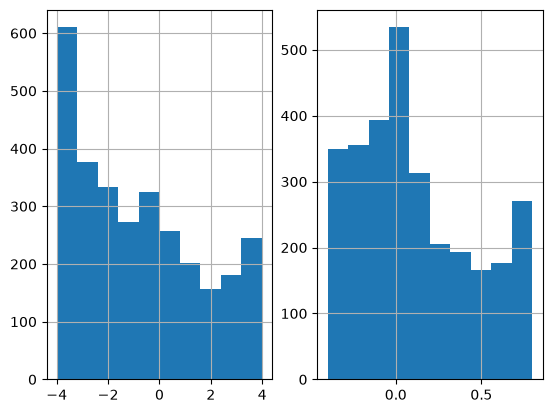

In [90]:
plt.subplot(1,2,1)
result_good.x1.hist()
plt.subplot(1,2,2)
result_good.c.hist()

In [91]:
result_good["reduced_chisq"] = result_good.chisq / result_good.ndof

<Axes: >

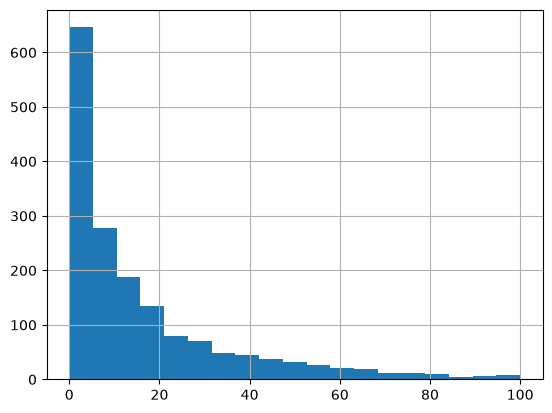

In [92]:
result_good.reduced_chisq.hist(bins = np.linspace(0, 100, 20))

In [93]:
sn_good = result_good.loc[(result_good.reduced_chisq > 0.) & (result_good.reduced_chisq < 20.)]

In [94]:
sn_good

diaObjectId_dia_object_lc  ra_dia_object_lc  dec_dia_object_lc  \
3            767459322346078223        343.337903          -17.26402   
4            769064746761584687         342.93668          -16.28705   
...                         ...               ...                ...   
2954         777099221823127692        309.497951          -8.633962   
2957         777124098273706239        313.645908          -7.579798   

      refExtendedness_object_lc  refSizeExtendedness_object_lc  \
3                           1.0                       0.718641   
4                           1.0                            1.0   
...                         ...                            ...   
2954                        1.0                       0.998119   
2957                        1.0                            1.0   

      objectId_object_lc  coord_ra_object_lc  coord_dec_object_lc  \
3     767459322346095347          343.338718           -17.263288   
4     769064746761608397          342.936598            -16.28703   
...                  ...                 ...                  ...   
2954  777099221823146656          309.497023            -8.634504   
2957  777124098273727801          313.646044            -7.580141   

      _dist_arcsec  ndet  ...  mwebv_z_cov  mwebv_t0_cov  mwebv_x0_cov  \
3         3.844891    10  ...          0.0           0.0           0.0   
4         0.291133    13  ...          0.0           0.0           0.0   
...            ...   ...  ...          ...           ...           ...   
2954      3.837806    28  ...          0.0           0.0           0.0   
2957      1.327952     7  ...          0.0           0.0           0.0   

      mwebv_x1_cov  mwebv_c_cov  mwebv_mwebv_cov                  id  \
3              0.0          0.0              0.0  767459322346078223   
4              0.0          0.0              0.0  769064746761584687   
...            ...          ...              ...                 ...   
2954           0.0          0.0              0.0  777099221823127692   
2957           0.0          0.0              0.0  777124098273706239   

      fit_error          _healpix_29  reduced_chisq  
3          None  1201605299817675827           -0.0  
4          None  1202222701112768358      10.606903  
...         ...                  ...            ...  
2954       None  3453196073611837139      -0.000004  
2957       None  3454880234289451069           -0.0  

[2003 rows x 108 columns]

<Axes: >

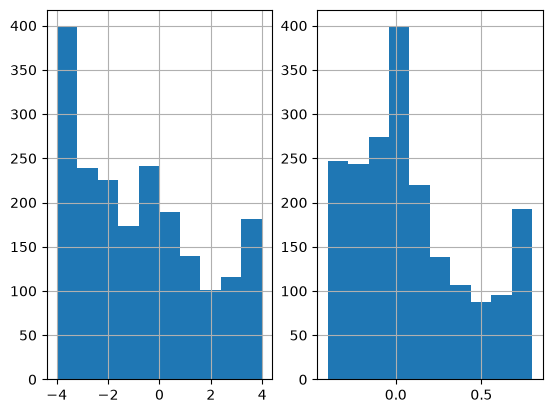

In [95]:
plt.subplot(1,2,1)
sn_good.x1.hist()
plt.subplot(1,2,2)
sn_good.c.hist()

In [96]:
# define quality cuts for lightcurves
def lc_quality_cuts(flux,mjd,filter,z,t0,n_phases=5, n_before_peak=1, n_after_peak=2, n_bands=3):
    phases = np.floor((mjd - t0)/(1. + z))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -10) & (unique_phases<=40)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    if np.sum(good_idx) == 0:
        return {"pass_quality_cuts": False}
    pass_before = np.sum(unique_phases[good_idx] < 0) >= n_before_peak
    pass_after = np.sum(unique_phases[good_idx] > 0) >= n_after_peak
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    pass_cut &= pass_before
    pass_cut &= pass_after
    pass_cut &= len(np.unique(filter[(phases >=-10) & (phases <=40)])) >= n_bands
    return {"pass_quality_cuts": pass_cut}

In [97]:
sn = sn_good

In [98]:
sn["diaObjectForcedSource_dia_object_lc.snr"] = sn["diaObjectForcedSource_dia_object_lc.psfDiffFlux"]/sn["diaObjectForcedSource_dia_object_lc.psfDiffFluxErr"]
sn_det = sn.query("diaObjectForcedSource_dia_object_lc.snr > 5")
pass_quality_cut = sn_det.map_rows(lc_quality_cuts,columns=["diaObjectForcedSource_dia_object_lc.psfDiffFlux",
                               "diaObjectForcedSource_dia_object_lc.midpointMjdTai",
                               "diaObjectForcedSource_dia_object_lc.band","z","t0"],
                               row_container="args")
idx = pass_quality_cut.query("pass_quality_cuts == True").index
sn["pass_quality_cuts"] = False
sn.loc[idx,"pass_quality_cuts"] = True
sn = sn[sn["pass_quality_cuts"] == True]

In [99]:
sn

diaObjectId_dia_object_lc  ra_dia_object_lc  dec_dia_object_lc  \
9            772330914771370002        346.395263         -12.876365   
32           780630165976776731        355.704522          -5.890017   
...                         ...               ...                ...   
2950         775437791034081749        305.909759          -9.811309   
2953         777084515855106445        305.446129          -8.904394   

      refExtendedness_object_lc  refSizeExtendedness_object_lc  \
9                           1.0                            1.0   
32                          1.0                       0.950602   
...                         ...                            ...   
2950                        1.0                            1.0   
2953                        1.0                       0.985246   

      objectId_object_lc  coord_ra_object_lc  coord_dec_object_lc  \
9     772330914771390648           346.39426           -12.876543   
32    780630165976798657          355.704537            -5.889995   
...                  ...                 ...                  ...   
2950  775437791034099663          305.908904            -9.811663   
2953  777084515855127769          305.445227            -8.903351   

      _dist_arcsec  ndet  ...  mwebv_t0_cov  mwebv_x0_cov  mwebv_x1_cov  \
9         3.577101    22  ...           0.0           0.0           0.0   
32        0.096056    17  ...           0.0           0.0           0.0   
...            ...   ...  ...           ...           ...           ...   
2950      3.288966     7  ...           0.0           0.0           0.0   
2953      4.938959     7  ...           0.0           0.0           0.0   

      mwebv_c_cov  mwebv_mwebv_cov                  id  fit_error  \
9             0.0              0.0  772330914771370002       None   
32            0.0              0.0  780630165976776731       None   
...           ...              ...                 ...        ...   
2950          0.0              0.0  775437791034081749       None   
2953          0.0              0.0  777084515855106445       None   

              _healpix_29  reduced_chisq  pass_quality_cuts  
9     1205693261461293803       0.422049               True  
32    1223292466777989710       8.429406               True  
...                   ...            ...                ...  
2950  3452656114349362661       9.205771               True  
2953  3452814702446092572       8.076367               True  

[686 rows x 109 columns]

{'x0': 2.9859146180449164e-05, 'x1': 1.110017840901774, 'c': 0.5708742095665637, 'z': 0.17490147615648263, 'mwebv': 0.21425676418411752, 't0': 60858.69653945168}
dist,reduced_chi2= 4.348599730110091 10.350142422466792


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


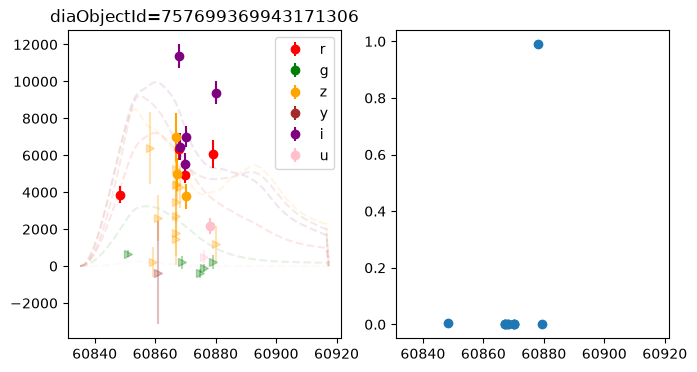

{'x0': 1.1309619938221377e-05, 'x1': 0.9028587348845741, 'c': 0.025853452101357022, 'z': 0.33972617533488336, 'mwebv': 0.08328915425459942, 't0': 60859.66427499302}
dist,reduced_chi2= 3.3145783429492828 4.8852049458648406


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


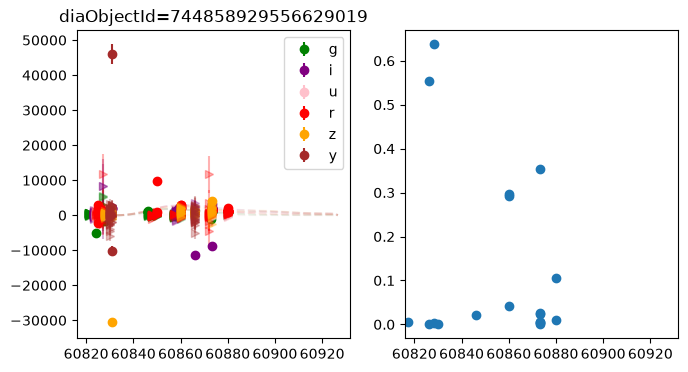

{'x0': 6.87769050427372e-05, 'x1': -3.161165844197626, 'c': -0.14256253150814377, 'z': 0.4479350517330985, 'mwebv': 0.06341768754781074, 't0': 60841.123737978065}
dist,reduced_chi2= 3.0120568015368425 4.144399846209909


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


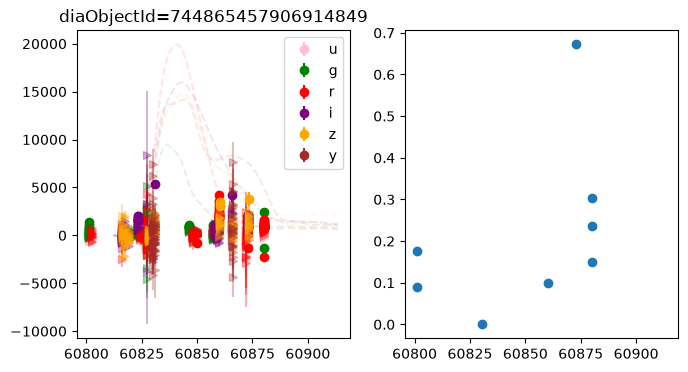

{'x0': 0.00018131007534610792, 'x1': -0.2907935406373302, 'c': -0.06150488746705851, 'z': 0.30123583938184956, 'mwebv': 0.06968663657993387, 't0': 60867.19776699756}
dist,reduced_chi2= 4.341484946053972 -8.885968838314276e-07


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


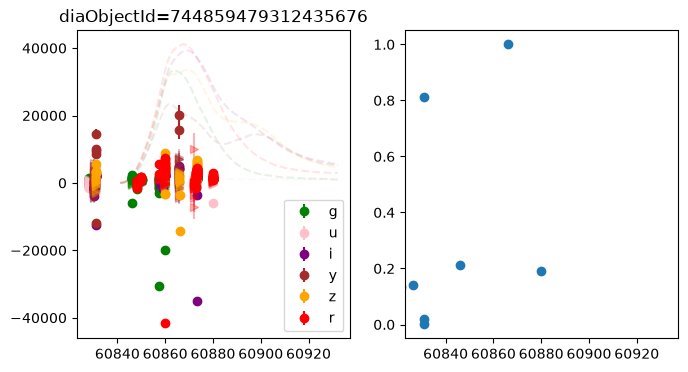

{'x0': 2.3224585189245372e-05, 'x1': -2.1762390871460546, 'c': 0.344751067223395, 'z': 0.28538029674211524, 'mwebv': 0.08228507048559987, 't0': 60850.7665461198}
dist,reduced_chi2= 1.1668294434548436 10.533397583766023


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


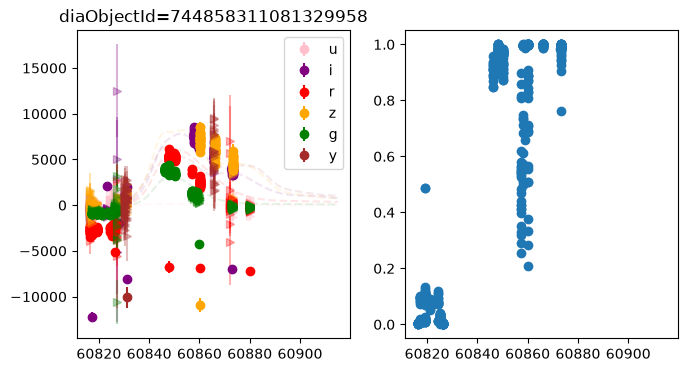

{'x0': 1.0771059050598074e-05, 'x1': -0.5209713334893348, 'c': 0.21167120189732924, 'z': 0.40784121127295575, 'mwebv': 0.0711784370854453, 't0': 60863.72005550688}
dist,reduced_chi2= 0.09533822155189368 1.1073092872079244


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


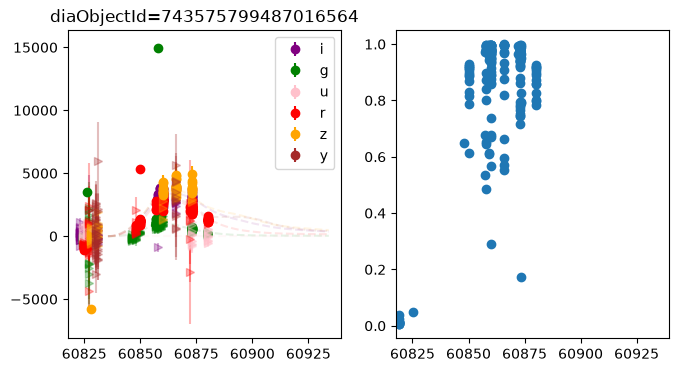

{'x0': 4.6500108354299646e-05, 'x1': -2.9441898996642957, 'c': 0.06701077785315256, 'z': 0.3554666271271044, 'mwebv': 0.09490244467514025, 't0': 60851.28135086644}
dist,reduced_chi2= 4.759152380824017 -44.91464545553451


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


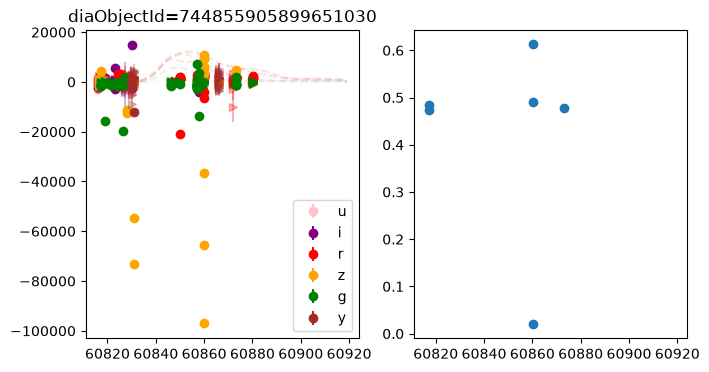

{'x0': 1.594267206150291e-05, 'x1': -0.1551921356923044, 'c': 0.47561785732546813, 'z': 0.2993975278344869, 'mwebv': 0.09580645093164149, 't0': 60869.51742173514}
dist,reduced_chi2= 4.938958956348958 8.07636683050586


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


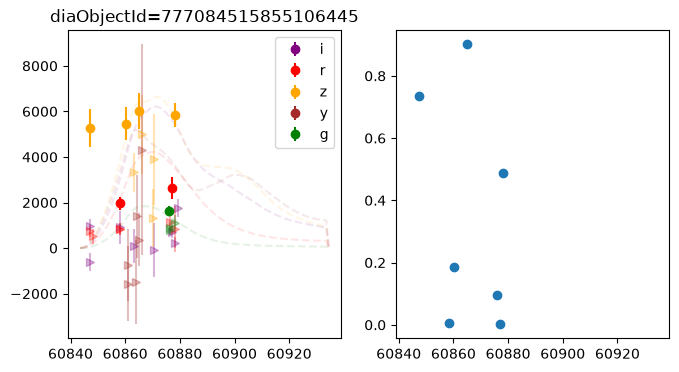

{'x0': 4.166485334414955e-05, 'x1': -1.9635657511416154, 'c': 0.3061801736738286, 'z': 0.31437527940653837, 'mwebv': 0.11164259398733715, 't0': 60861.3153736155}
dist,reduced_chi2= 4.591686912850004 5.300648879214172


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


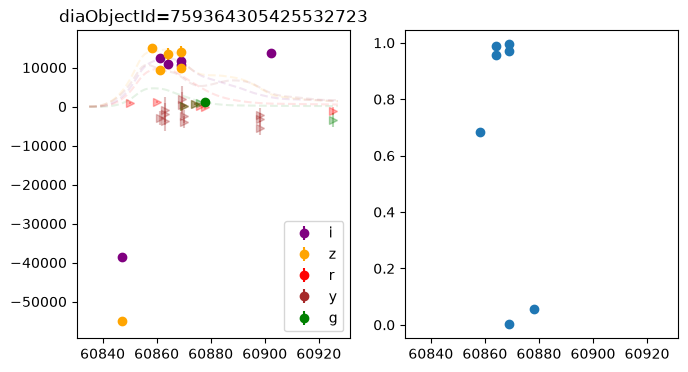

{'x0': 5.4684703478335284e-05, 'x1': -0.7457679364436963, 'c': -0.31988089024924277, 'z': 0.408701698618993, 'mwebv': 0.08236313659823445, 't0': 60843.82540572835}
dist,reduced_chi2= 4.667671056336903 4.74091897127756


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


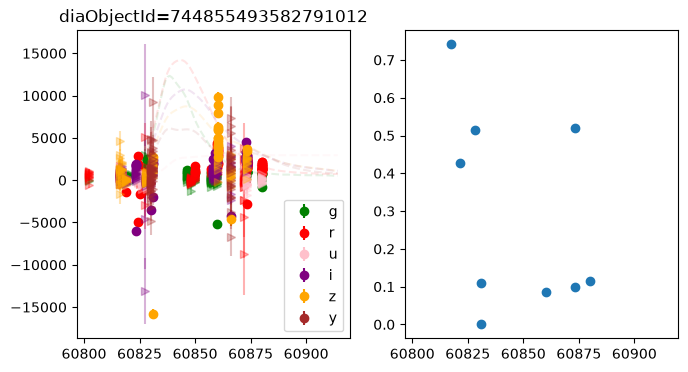

{'x0': 9.300535459034136e-06, 'x1': 0.31772610807044516, 'c': -0.35346279745667536, 'z': 0.3533950931585464, 'mwebv': 0.07780580067452178, 't0': 60856.71337706413}
dist,reduced_chi2= 2.9320492914494745 2.6622531664784583


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


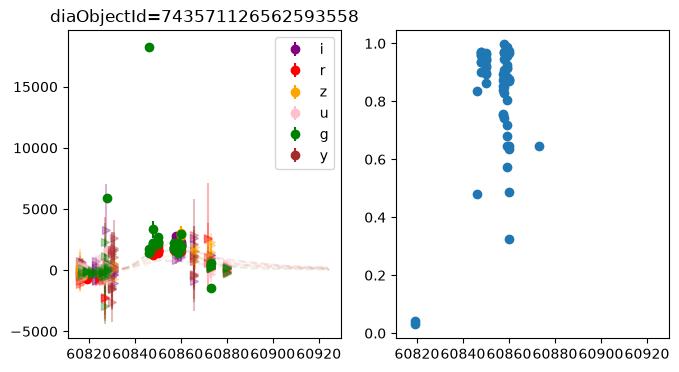

{'x0': 6.679337768677601e-05, 'x1': -0.7388746727477582, 'c': -0.039668128101918, 'z': 0.14862556431945376, 'mwebv': 0.06417648842105066, 't0': 60811.805622236025}
dist,reduced_chi2= 3.290300191204078 8.958757973595521


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


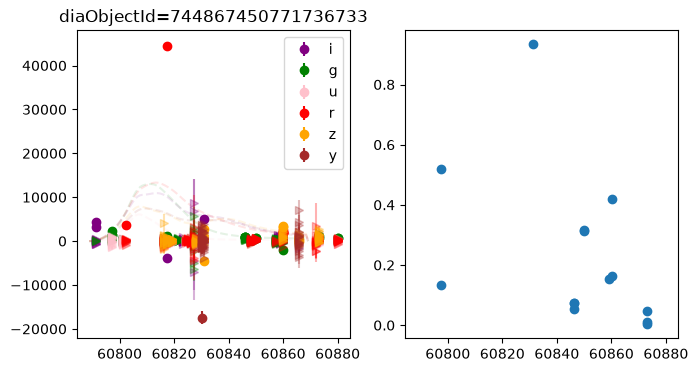

{'x0': 1.839677373106811e-05, 'x1': -3.756579814764428, 'c': 0.005258398128044914, 'z': 0.044320634699211096, 'mwebv': 0.013988566357371644, 't0': 60875.83893083863}
dist,reduced_chi2= 2.9612452513762935 3.122635661205757


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


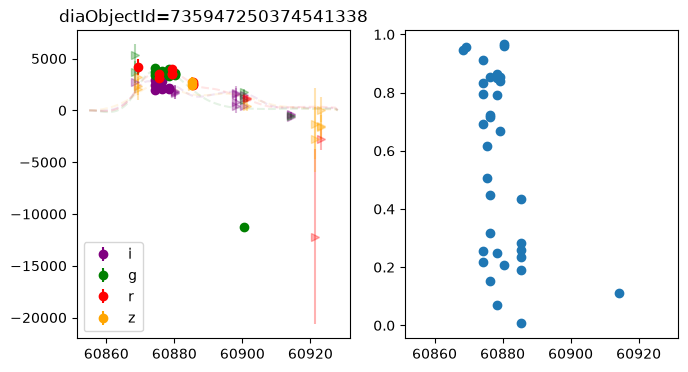

{'x0': 3.759235478057084e-05, 'x1': 0.9179916596109219, 'c': 0.0742953359275749, 'z': 2.261383518322841e-10, 'mwebv': 0.08082595949296059, 't0': 60833.68856124739}
dist,reduced_chi2= 4.155080157739409 14.763035677407363


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


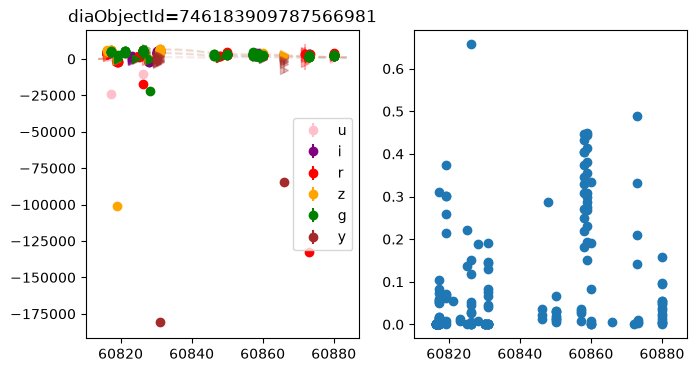

{'x0': 7.506225661818558e-06, 'x1': 0.7185630513593224, 'c': 0.6602847046866575, 'z': 0.29410961155407805, 'mwebv': 0.07155266337594188, 't0': 60855.36904085469}
dist,reduced_chi2= 4.722044852895737 4.540512707433254


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


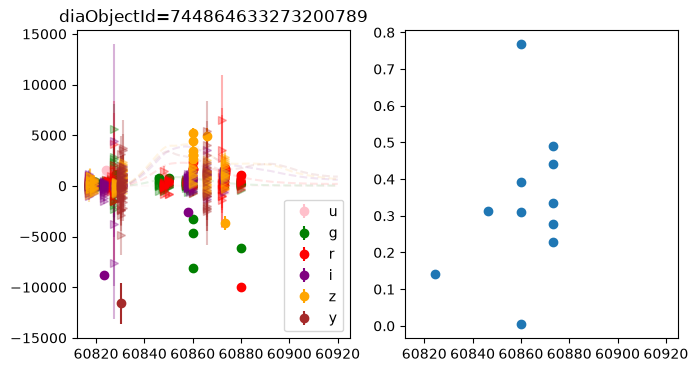

{'x0': 0.004799573291255889, 'x1': -3.902683718623704, 'c': -0.37895901067674753, 'z': 0.32868253775378914, 'mwebv': 0.05402550353130092, 't0': 60911.484164262445}
dist,reduced_chi2= 4.831175934597855 -250.86796794195195


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


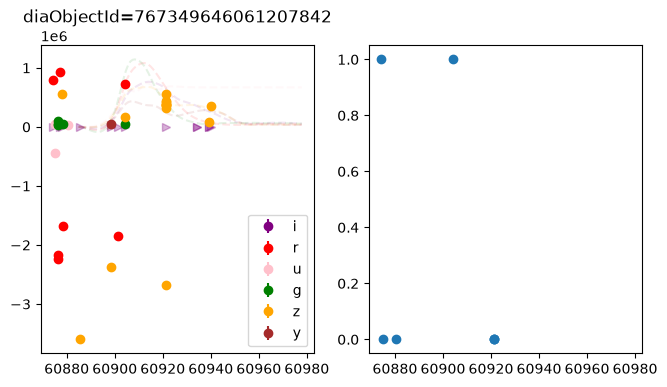

{'x0': 0.00013411723333643554, 'x1': -3.720243438506905, 'c': -0.13967289153649243, 'z': 0.34473321012111136, 'mwebv': 0.08077813847954252, 't0': 60804.95313646823}
dist,reduced_chi2= 3.9952176340464596 13.200372495077225


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


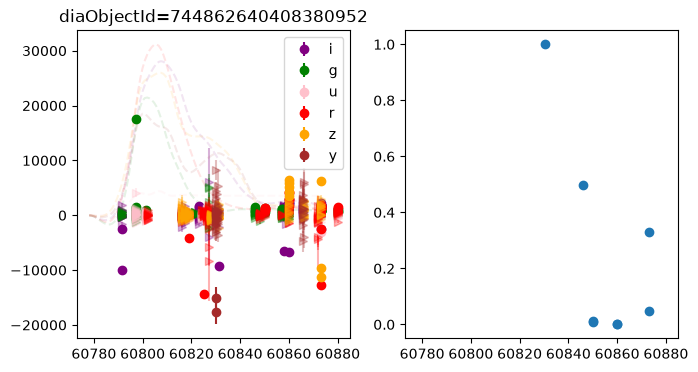

{'x0': 8.858982568911561e-06, 'x1': -0.670199333803324, 'c': 0.7976937060410295, 'z': 0.27535072575386077, 'mwebv': 0.07258535731719455, 't0': 60854.48577672904}
dist,reduced_chi2= 3.614318871431392 3.0990152773230033


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


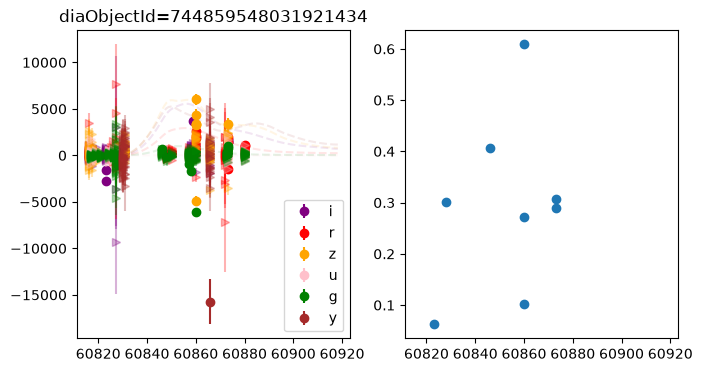

{'x0': 1.9161726779894793e-05, 'x1': -0.5343386756730127, 'c': -0.3344062719782762, 'z': 0.1135565967248014, 'mwebv': 0.07613836268837146, 't0': 60859.85674527943}
dist,reduced_chi2= 1.8809298609748784 9.67768373088926


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


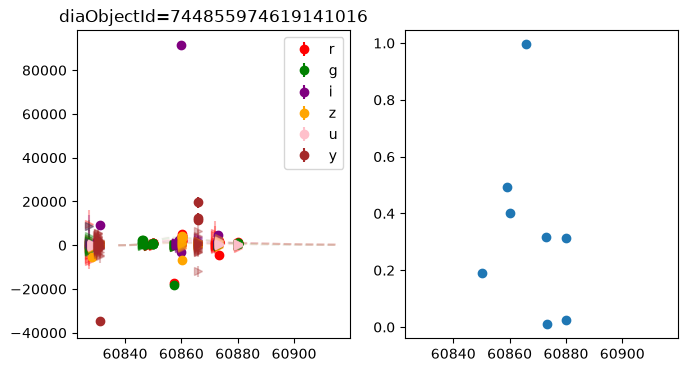

{'x0': 1.1425899466256026e-05, 'x1': -2.267650775583605, 'c': -0.3266613256296854, 'z': 0.4645809358194725, 'mwebv': 0.0446181789628677, 't0': 60909.41218507832}
dist,reduced_chi2= 3.2171355718858514 1.689534675326131


/local/tmp/ipykernel_2709912/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


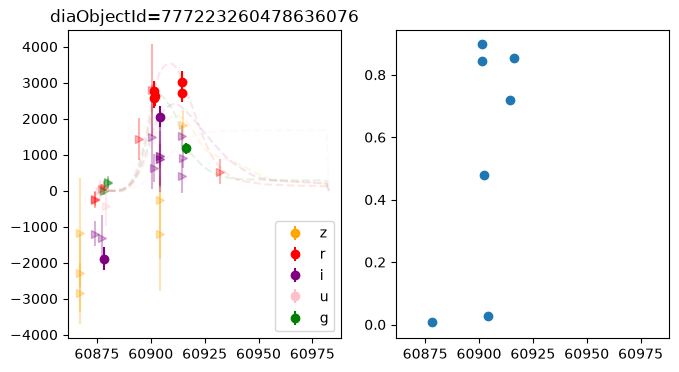

In [100]:
from legacy_survey_cutout import plot_legacy_cutout
cols = ["x0","x1","c","z","mwebv","t0"]
for i in np.random.choice(len(sn),size=np.min([20,len(sn)]),replace=False):
    saltpars_df = result_good.loc[result_good.id==sn.iloc[i]["diaObjectId_dia_object_lc"]]
    saltpars = {}
    for col in cols:
        saltpars[col] = saltpars_df[col].values[0]
    print(saltpars)
    print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))
    plt.figure(figsize=(12,4))
    ax = plt.subplot(1,3,1)
    lc = sn.iloc[i]["diaObjectForcedSource_dia_object_lc"]
    lc = lc[["midpointMjdTai","band","psfDiffFlux","psfDiffFluxErr"]]
    phase = (lc["midpointMjdTai"] - saltpars["t0"])/(1.+saltpars["z"])
    good_phase = (phase > -30) & (phase < 100)
    lc = lc.loc[good_phase]
    lc["mjd"] = lc["midpointMjdTai"]
    lc["flux"] = lc["psfDiffFlux"]
    lc["fluxerr"] = lc["psfDiffFluxErr"]
    lc["snr"] = lc["flux"]/lc["fluxerr"]
    # lc_coadd = nightly_coadd(lc["mjd"],lc["band"],lc["flux"],lc["fluxerr"])
    # lc_coadd["snr"] = lc_coadd["flux"]/lc_coadd["fluxerr"]
    # plot_lc(lc_coadd,saltpars=saltpars)
    plot_lc(lc,saltpars=saltpars)
    plt.title(f"diaObjectId={sn.iloc[i]['diaObjectId_dia_object_lc']}")
    # plt.subplot(1,3,1)
    # lc = sn.iloc[i]["diaSource_dia_object_lc"]
    # lc["mjd"] = lc["midpointMjdTai"]
    # lc["flux"] = lc["psfFlux"]
    # lc["fluxerr"] = lc["psfFluxErr"]
    # lc["snr"] = lc["flux"]/lc["fluxerr"]
    # plot_lc(lc,saltpars=saltpars)
    ax2 = plt.subplot(1,3,2)
    plt.plot(sn.iloc[i]["diaSource_dia_object_lc"]["midpointMjdTai"],sn.iloc[i]["diaSource_dia_object_lc"]["reliability"],'o')
    plt.xlim(ax.get_xlim())
    # ax = plt.subplot(1,3,3)
    # ra = sn.iloc[i]["ra_dia_object_lc"]
    # dec = sn.iloc[i]["dec_dia_object_lc"]
    # img = plot_legacy_cutout(ra, dec, size=115, pixscale=0.262, layer="ls-dr10", fmt="jpg",ax=ax)
    plt.show()

In [101]:
sn.to_parquet(outdir / "final_sample.parquet")

In [ ]:
# Preserve scalar diagnostics for candidates omitted from the final sample.
from candidate_audit import main as export_candidate_audit

audit_suffix = "_ddf" if DDF else ""
export_candidate_audit([
    "--initial-catalog", str(outdir / sncandid_filename),
    "--initial-output", str(outdir / f"initial_candidate_audit{audit_suffix}.parquet"),
    "--salt-catalog", str(outdir / saltres_file),
    "--final-sample", str(outdir / "final_sample.parquet"),
    "--output", str(outdir / f"salt_candidate_audit{audit_suffix}.parquet"),
])